# 02 - Data cleaning and exploratory analysis

**Goal:** confirm data quality in Python, investigate outliers, flag suspicious rows,
and visualize the distributions.

The habit that matters here is **flag, don't delete**. Removing rows after randomization
can break the fairness that randomization created, so every suspicious row gets a flag
column and stays in the dataset. Analyses can then be run both ways.

In [1]:
import pandas as pd                    # tables and data cleaning
import numpy as np                     # fast maths on arrays
import matplotlib.pyplot as plt        # base plotting library
import seaborn as sns                  # nicer statistical plots built on matplotlib
from pathlib import Path               # file paths that work on every operating system

sns.set_theme(style="whitegrid")       # clean chart style with light grid lines
pd.set_option("display.float_format", "{:.4f}".format)     # show decimals neatly in tables
pd.set_option("display.max_columns", None)                 # never hide columns when printing tables
pd.set_option("display.width", 200)                        # allow wide tables to print on one line

In [2]:
ROOT = Path.cwd()                      # folder the notebook runs in
if ROOT.name == "notebooks":           # if we are inside notebooks/...
    ROOT = ROOT.parent                 # ...go up to the project root
RAW_FILE = ROOT / "data" / "raw" / "cookie_cats.csv"               # raw input
CLEAN_FILE = ROOT / "data" / "processed" / "cookie_cats_clean.csv" # cleaned output
FIG_DIR = ROOT / "reports" / "figures"                             # where charts are saved
FIG_DIR.mkdir(parents=True, exist_ok=True)                         # create the figures folder if needed
CLEAN_FILE.parent.mkdir(parents=True, exist_ok=True)               # create the processed folder if needed

In [3]:
df = pd.read_csv(RAW_FILE)             # read the CSV into a DataFrame (a table)
print(df.shape)                        # (rows, columns) -> expect (90189, 5)
print(df.dtypes)                       # data type of each column
print(df.head())                       # first 5 rows

(90189, 5)
userid            int64
version             str
sum_gamerounds    int64
retention_1        bool
retention_7        bool
dtype: object
   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True


**Checkpoint:** `(90189, 5)`. `retention_1` and `retention_7` are `bool`.
`version` shows as `object` on pandas 2 or `str` on pandas 3; both are fine.

In [4]:
print("Missing values per column:")    # heading for the next print
print(df.isna().sum())                 # count of empty cells per column -> expect all 0
print("Duplicate userids:", df["userid"].duplicated().sum())            # expect 0
print("Version labels:", df["version"].unique())                        # expect only gate_30 and gate_40
print("Negative rounds:", (df["sum_gamerounds"] < 0).sum())             # rounds can never be negative -> expect 0
print("retention_1 type:", df["retention_1"].dtype)                     # should be bool (True/False)
print("retention_7 type:", df["retention_7"].dtype)                     # should be bool (True/False)

Missing values per column:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64
Duplicate userids: 0
Version labels: <ArrowStringArray>
['gate_30', 'gate_40']
Length: 2, dtype: str
Negative rounds: 0
retention_1 type: bool
retention_7 type: bool


In [5]:
summary = df.groupby("version").agg(                  # group rows by test version and calculate:
    players=("userid", "count"),                      # number of players
    d1_retention=("retention_1", "mean"),             # mean of True/False = share of True = retention rate
    d7_retention=("retention_7", "mean"),             # same for day 7
    mean_rounds=("sum_gamerounds", "mean"),           # average rounds
    median_rounds=("sum_gamerounds", "median"),       # median rounds
    max_rounds=("sum_gamerounds", "max"),             # largest value
)
print(summary)                                        # show the table

         players  d1_retention  d7_retention  mean_rounds  median_rounds  max_rounds
version                                                                             
gate_30    44700        0.4482        0.1902      52.4563        17.0000       49854
gate_40    45489        0.4423        0.1820      51.2988        16.0000        2640


The mean of a True/False column is the share of True values, which is why `mean`
on `retention_1` gives the retention rate directly.

In [6]:
print(df.nlargest(5, "sum_gamerounds"))                    # the 5 players with the most rounds
top_value = df["sum_gamerounds"].max()                     # the single largest value
second_value = df["sum_gamerounds"].nlargest(2).iloc[1]    # the second largest value
print("Largest:", top_value, "| Second largest:", second_value)          # compare them
rounds_per_day = top_value / 14                            # spread over 14 days (the longest window sources mention)
print("Rounds per day if spread over 14 days:", round(rounds_per_day))   # about 3,561 per day
max_possible_per_day = 24 * 60 * 2                         # even at 30 seconds per round with zero breaks for 24 hours
print("Max rounds per day at 30s/round, 24h non-stop:", max_possible_per_day)   # 2,880 per day

        userid  version  sum_gamerounds  retention_1  retention_7
57702  6390605  gate_30           49854        False         True
7912    871500  gate_30            2961         True         True
29417  3271615  gate_40            2640         True        False
43671  4832608  gate_30            2438         True         True
48188  5346171  gate_40            2294         True         True
Largest: 49854 | Second largest: 2961
Rounds per day if spread over 14 days: 3561
Max rounds per day at 30s/round, 24h non-stop: 2880


**Checkpoint:** largest 49,854, second largest 2,961, about 3,561 rounds per day, ceiling 2,880 per day.

Even at 30 seconds per round with no sleep and no breaks, a player could manage at most
2,880 rounds per day. 49,854 rounds would need about 3,561 per day over the longest
window anyone claims for this metric. The value is physically impossible, so it is
almost certainly a logging error or a bot.

In [7]:
df["is_implausible_rounds"] = df["sum_gamerounds"] > 10000                # True only for physically impossible values
df["is_zero_rounds"] = df["sum_gamerounds"] == 0                          # installed but never played a round
df["zero_rounds_but_retained"] = df["is_zero_rounds"] & (df["retention_1"] | df["retention_7"])  # "came back and played" yet 0 rounds
print("Implausible rounds rows:", df["is_implausible_rounds"].sum())      # expect 1
print("Zero-round players:", df["is_zero_rounds"].sum())                  # expect 3,994
print("Zero rounds but marked retained:", df["zero_rounds_but_retained"].sum())   # a data-quality inconsistency to report
print(pd.crosstab(df["version"], df["zero_rounds_but_retained"]))         # is the inconsistency similar in both groups?

Implausible rounds rows: 1
Zero-round players: 3994
Zero rounds but marked retained: 111
zero_rounds_but_retained  False  True 
version                               
gate_30                   44644     56
gate_40                   45434     55


**Checkpoint:** 1 implausible row, 3,994 zero-round players, 111 players with zero rounds
but marked retained (56 in gate_30, 55 in gate_40).

- **Why flag instead of delete?** Deleting rows after randomization can make the groups unfair.
  Flags let us run the analysis both ways and show whether the decision changes.
- **The 111 inconsistent players.** The dataset describes retention as "came back and played",
  yet these players have zero rounds. It is a data-quality issue worth reporting, and because
  it is nearly identical in both groups (56 vs 55) it is unlikely to bias the comparison.
- **Zero-round players stay in.** They were randomized, and intention-to-treat means
  everyone assigned is analyzed.

In [8]:
print(pd.crosstab(df["retention_1"], df["retention_7"], margins=True))    # counts for each True/False combination

retention_7  False   True    All
retention_1                     
False        46437   3599  50036
True         26971  13182  40153
All          73408  16781  90189


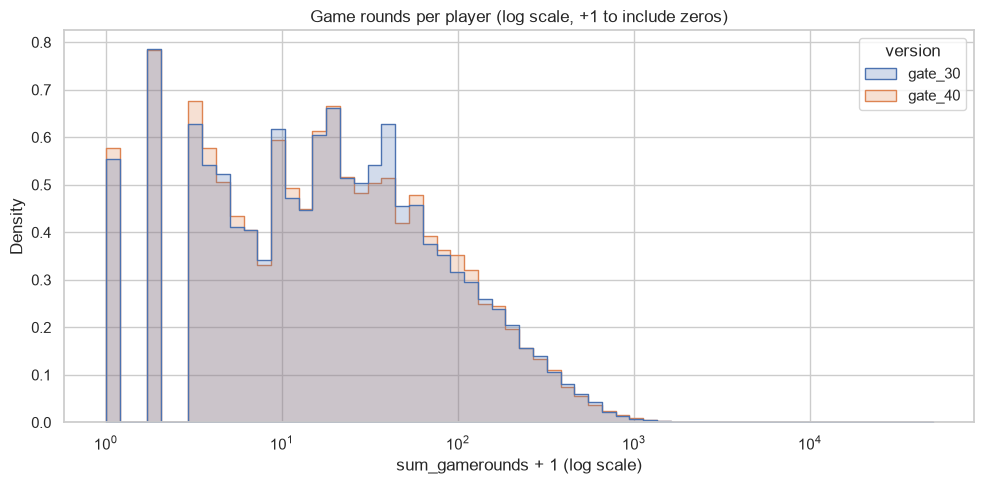

In [9]:
df["rounds_plus_1"] = df["sum_gamerounds"] + 1        # add 1 so zero rounds can be drawn on a log scale (log of 0 is undefined)
fig, ax = plt.subplots(figsize=(10, 5))               # create an empty chart 10 x 5 inches
sns.histplot(data=df, x="rounds_plus_1", hue="version", log_scale=True, bins=60, element="step", stat="density", common_norm=False, ax=ax)  # overlaid histograms
ax.set_title("Game rounds per player (log scale, +1 to include zeros)")   # chart title
ax.set_xlabel("sum_gamerounds + 1 (log scale)")       # x-axis label
ax.set_ylabel("Density")                              # y-axis label
fig.tight_layout()                                    # avoid overlapping labels
fig.savefig(FIG_DIR / "01_rounds_distribution_log.png", dpi=150)          # save the chart as an image
plt.show()                                            # display the chart in the notebook

A log scale spreads out values that range from 0 to 50,000, so the thousands of casual
players and the rare heavy players fit on one chart. Note the bump in gate_30 shortly
after 30 rounds - notebook 06 looks at it closely.

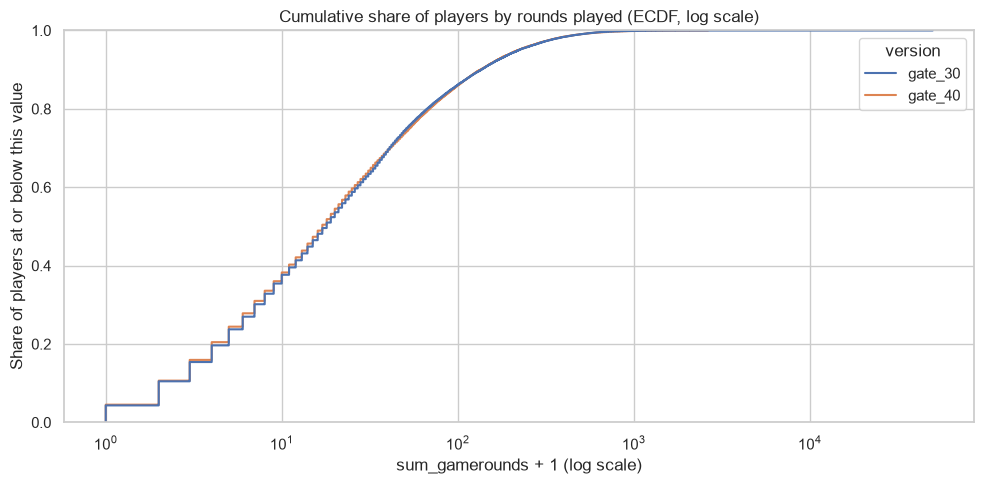

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))               # new empty chart
sns.ecdfplot(data=df, x="rounds_plus_1", hue="version", log_scale=True, ax=ax)   # cumulative share of players at or below each value
ax.set_title("Cumulative share of players by rounds played (ECDF, log scale)")   # title
ax.set_xlabel("sum_gamerounds + 1 (log scale)")       # x-axis label
ax.set_ylabel("Share of players at or below this value")   # y-axis label
fig.tight_layout()                                    # tidy spacing
fig.savefig(FIG_DIR / "02_rounds_ecdf.png", dpi=150)  # save
plt.show()                                            # display

An ECDF shows, for each value, the share of players at or below it. The two lines sit
almost on top of each other, so the two rounds distributions are very similar.

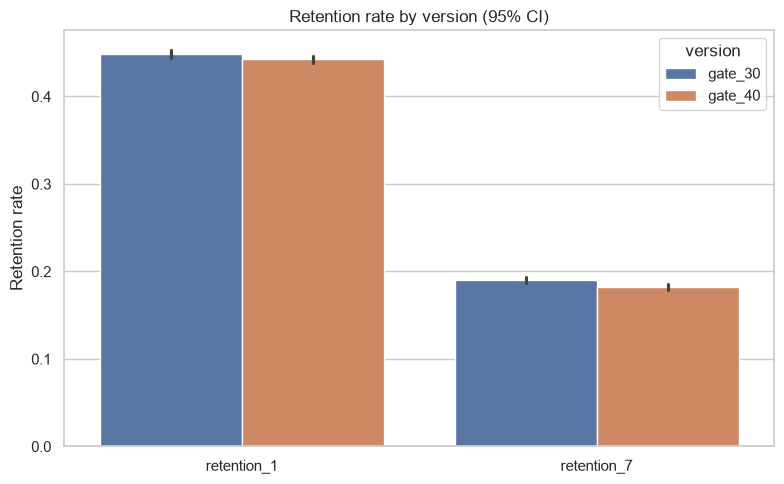

In [11]:
retention_long = df.melt(id_vars="version", value_vars=["retention_1", "retention_7"], var_name="metric", value_name="retained")  # reshape to long format for seaborn
fig, ax = plt.subplots(figsize=(8, 5))                # new chart
sns.barplot(data=retention_long, x="metric", y="retained", hue="version", errorbar=("ci", 95), ax=ax)  # bars = mean retention, lines = 95% CI
ax.set_title("Retention rate by version (95% CI)")    # title
ax.set_ylabel("Retention rate")                       # y-axis label
ax.set_xlabel("")                                     # no x-axis label needed
fig.tight_layout()                                    # tidy spacing
fig.savefig(FIG_DIR / "03_retention_rates.png", dpi=150)   # save
plt.show()                                            # display

In [12]:
df_to_save = df.drop(columns=["rounds_plus_1"])       # drop the helper column used only for plotting
df_to_save.to_csv(CLEAN_FILE, index=False)            # save the cleaned table with the flag columns
print("Saved:", CLEAN_FILE, df_to_save.shape)         # confirm (90189 rows, 8 columns)

Saved: D:\Analytics\CookieCats-A-B-Test\data\processed\cookie_cats_clean.csv (90189, 8)


**Checkpoint:** `(90189, 8)` and three charts saved in `reports/figures/`.